In [5]:
import os
import re
import pickle
import numpy as np
from collections import Counter
from tqdm import tqdm
from PIL import Image
import tensorflow as tf
from tensorflow.keras.applications import ResNet50
from tensorflow.keras.applications.resnet50 import preprocess_input
from tensorflow.keras.models import Model
from tensorflow import keras
from tensorflow.keras import layers, Model
from tensorflow.keras.layers import (
    Input, Dense, Embedding, LSTM, Concatenate,
    Dropout, BatchNormalization,RepeatVector
)
from tensorflow.keras.models import load_model
from tensorflow.keras.preprocessing.sequence import pad_sequences


Loading file and preprocessing

Read caption file

In [6]:
def load_captions(captions_file: str) ->dict:
    
    captions={}
    with open(captions_file, "r") as f:
        for line in f:
            line=line.strip()
            if not line:
                continue
            if line.lower().startswith("image,"):
                continue
            parts = line.split(",", 1)   # comma delimiter
            if len(parts)!=2:
                continue
            image_id, caption=parts
            image_id=image_id.strip()
            caption=caption.strip()
            if image_id not in captions:
                captions[image_id]=[]
            captions[image_id].append(caption)
    print(f"Loaded caption for {len(captions)} image")
    return captions


 Cleans a single caption:
    - Lowercase
    - Remove punctuation & numbers
    - Remove single-character words (except 'a')
    - Strip extra whitespace
    


In [7]:
def clean_caption(caption: str) -> str:
    caption=caption.lower()
    caption=re.sub(r"[^a-z\s]", "", caption)
    tokens=caption.split()
    tokens= [t for t in tokens if len(t) > 1 or t in ("a", "i")]
    return " ".join(tokens)

def clean_all_captions(captions: dict) -> dict:
    cleaned={}
    for image_id, cap_list in captions.items():
        cleaned[image_id]=[]
        for cap in cap_list:
            cap=clean_caption(cap)
            cap="startseq " + cap + " endseq"
            cleaned[image_id].append(cap)
    print(f" Cleaned all captions")
    return cleaned
 

In [8]:
def build_vocabulary(captions: dict, min_freq: int = 2):
    counter=Counter()
    for cap_list in captions.values():
        for cap in cap_list:
            counter.update(cap.split())
    special={"<pad>","<unk>","startseq","endseq"}
    vocab = [word for word, freq in counter.items() 
             if freq >= min_freq and word not in special]
    vocab=sorted(vocab)
    vocab=["<pad>", "<unk>", "startseq", "endseq"] + vocab
    word2idx={word: idx for idx, word in enumerate(vocab)}
    idx2word={idx: word for word, idx in word2idx.items()}
    print(f" Vocabulary size: {len(word2idx)} words (min_freq={min_freq})")
    return word2idx, idx2word

 Reads a Flickr8k split file (train / val / test).
    Each line contains one image filename.
    

In [9]:
def load_split(split_file: str) -> set:
    with open(split_file, "r") as f:
        filenames = set(line.strip() for line in f if line.strip())
    print(f" Loaded split: {len(filenames)} images from '{split_file}'")
    return filenames

Returns only captions for images in the given split

In [10]:
 
def filter_captions_by_split(captions: dict, split: set) -> dict:
    return {img: caps for img, caps in captions.items() if img in split}

  Returns the length of the longest caption.
    Used for padding sequences during training.

In [11]:
def get_max_length(captions: dict) -> int:
    max_len = max(
        len(cap.split())
        for cap_list in captions.values()
        for cap in cap_list
    )
    print(f"Max caption length: {max_len} tokens")
    return max_len

In [12]:
DATA_DIR="data/flickr8k"
CAPTIONS_FILE=os.path.join(DATA_DIR, "captions.txt")
TRAIN_FILE=os.path.join(DATA_DIR, "train.txt")
VAL_FILE =os.path.join(DATA_DIR, "val.txt")
TEST_FILE =os.path.join(DATA_DIR, "test.txt")
OUTPUT_DIR="data/processed"
os.makedirs(OUTPUT_DIR, exist_ok=True)   
captions=load_captions(CAPTIONS_FILE)
captions=clean_all_captions(captions)
word2idx, idx2word=build_vocabulary(captions, min_freq=5)
train_imgs=load_split(TRAIN_FILE)
val_imgs = load_split(VAL_FILE)
test_imgs= load_split(TEST_FILE)
train_captions= filter_captions_by_split(captions, train_imgs)
val_captions= filter_captions_by_split(captions, val_imgs)
max_length = get_max_length(train_captions)
with open(os.path.join(OUTPUT_DIR, "word2idx.pkl"), "wb") as f:
        pickle.dump(word2idx, f)
with open(os.path.join(OUTPUT_DIR, "idx2word.pkl"), "wb") as f:
        pickle.dump(idx2word, f)
with open(os.path.join(OUTPUT_DIR, "train_captions.pkl"), "wb") as f:
        pickle.dump(train_captions, f)
with open(os.path.join(OUTPUT_DIR, "val_captions.pkl"), "wb") as f:
        pickle.dump(val_captions, f)
with open(os.path.join(OUTPUT_DIR, "max_length.pkl"), "wb") as f:
        pickle.dump(max_length, f) 
print("\n Preprocessing complete. Files saved to:", OUTPUT_DIR)
print(f"    Vocab size : {len(word2idx)}")
print(f"    Train imgs : {len(train_captions)}")
print(f"    Val imgs   : {len(val_captions)}")
print(f"    Max length : {max_length}")


Loaded caption for 8091 image
 Cleaned all captions
 Vocabulary size: 2987 words (min_freq=5)
 Loaded split: 5663 images from 'data/flickr8k/train.txt'
 Loaded split: 1213 images from 'data/flickr8k/val.txt'
 Loaded split: 1215 images from 'data/flickr8k/test.txt'
Max caption length: 35 tokens

 Preprocessing complete. Files saved to: data/processed
    Vocab size : 2987
    Train imgs : 5663
    Val imgs   : 1213
    Max length : 35


In [13]:
print("startseq" in word2idx)
print("endseq" in word2idx)

True
True


In [ ]:
def build_feature_extractor() -> Model:
    base_model=ResNet50(weights="imagenet",include_top=False,pooling="avg",input_shape=(224, 224, 3))
    base_model.trainable=False
    print(f"[✓] ResNet50 extractor ready")
    print(f"    Input  : {base_model.input_shape}")
    print(f"    Output : {base_model.output_shape}")
    return base_model

    Loads an image and prepares it for the mode restnet50

In [ ]:
def load_and_preprocess(image_path: str) -> np.ndarray: 
    img=Image.open(image_path).convert("RGB")
    img=img.resize((224, 224))   # (224,224,3)
    arr=np.array(img, dtype=np.float32)           
    arr=np.expand_dims(arr, axis=0)               
    arr=preprocess_input(arr)                    
    return arr

Runs every image through the extractor in batches.
    
 

In [ ]:
def extract_all_features(image_dir: str, model: Model, batch_size: int = 32) -> dict:
    image_files = [
        f for f in os.listdir(image_dir)
        if f.lower().endswith((".jpg", ".jpeg", ".png"))
    ]
    print(f"Extracting features from {len(image_files)} images (batch_size={batch_size})...")
    features={}
    batches= [image_files[i:i+batch_size] for i in range(0, len(image_files), batch_size)]
    for batch in tqdm(batches, desc="Extracting"):
        imgs, names= [], []
        for fname in batch:
            path= os.path.join(image_dir, fname)
            try:
                imgs.append(load_and_preprocess(path)[0])   # (224,224,3)
                names.append(fname)
            except Exception as e:
                print(f"[!] Skipping {fname}: {e}")
        if not imgs:
            continue
        batch_arr= np.stack(imgs)                          
        batch_feat= model.predict(batch_arr, verbose=0)     
        for name, feat in zip(names, batch_feat):
            features[name] = feat                           
    print(f"[✓] Extracted features for {len(features)} images")
    return features

In [ ]:
DATA_DIR="data/flickr8k"
IMAGE_DIR=os.path.join(DATA_DIR, "images")
OUTPUT_DIR="data/processed"
os.makedirs(OUTPUT_DIR, exist_ok=True)
gpus=tf.config.list_physical_devices("GPU")
for gpu in gpus:
    tf.config.experimental.set_memory_growth(gpu, True)
print(f"[i] GPUs available: {len(gpus)}")
extractor=build_feature_extractor()
features=extract_all_features(IMAGE_DIR, extractor, batch_size=32)
out_path=os.path.join(OUTPUT_DIR, "image_features.pkl")
with open(out_path, "wb") as f:
    pickle.dump(features, f)
sample_shape = next(iter(features.values())).shape
print(f"\n[✓] Features saved to : {out_path}")
print(f"    Total images       : {len(features)}")
print(f"    Feature shape      : {sample_shape}")
print(f"    File size          : {os.path.getsize(out_path) / 1e6:.1f} MB")

[i] GPUs available: 0
[✓] ResNet50 extractor ready
    Input  : (None, 224, 224, 3)
    Output : (None, 2048)
[→] Extracting features from 8091 images (batch_size=32)...


Extracting:   0%|          | 0/253 [00:04<?, ?it/s]


KeyboardInterrupt: 

In [ ]:
def build_model(vocab_size, max_length, feature_dim=2048,encoder_dim=256,embed_dim=128,decoder_dim=256,dropout_rate=0.5):
    image_input=Input(shape=(feature_dim,), name="image_input")
    img_proj= Dense(encoder_dim, activation="relu")(image_input)
    img_proj= BatchNormalization()(img_proj)
    img_proj= Dropout(dropout_rate)(img_proj)
    img_repeat= RepeatVector(max_length)(img_proj)
    caption_input = Input(shape=(max_length,), name="caption_input")
    embed = Embedding(vocab_size, embed_dim)(caption_input)  
    embed = Dropout(dropout_rate)(embed)
    combined = Concatenate(axis=-1)([img_repeat, embed])
    lstm_out = LSTM(decoder_dim)(combined)
    lstm_out = Dropout(dropout_rate)(lstm_out)
    output = Dense(vocab_size, activation="softmax")(lstm_out)
    return Model(inputs=[image_input, caption_input], outputs=output)

In [ ]:
def compile_model(model: Model, learning_rate: float = 1e-3) -> Model:
    model.compile(optimizer=keras.optimizers.Adam(learning_rate=learning_rate),loss= "categorical_crossentropy", metrics=["accuracy"])
    return model


In [19]:
VOCAB_SIZE  = len(word2idx)   
MAX_LENGTH  = max_length      
BATCH_SIZE  = 4
model = build_model(vocab_size=VOCAB_SIZE, max_length=MAX_LENGTH)
model = compile_model(model)
model.summary()
total = model.count_params()
print(f"[✓] Total parameters: {total:,}")


2026-04-23 19:26:03.292867: E external/local_xla/xla/stream_executor/cuda/cuda_platform.cc:51] failed call to cuInit: INTERNAL: CUDA error: Failed call to cuInit: UNKNOWN ERROR (303)


Model: "functional"

┏━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┓
┃ Layer (type)        ┃ Output Shape      ┃    Param # ┃ Connected to      ┃
┡━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━┩
│ image_input         │ (None, 2048)      │          0 │ -                 │
│ (InputLayer)        │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dense (Dense)       │ (None, 256)       │    524,544 │ image_input[0][0] │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ batch_normalization │ (None, 256)       │      1,024 │ dense[0][0]       │
│ (BatchNormalizatio… │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ caption_input       │ (None, 35)        │          0 │ -                 │
│ (InputLayer)        │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dropout (Dropout)   │ (None, 256)       │          0 │ batch_normalizat… │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ embedding           │ (None, 35, 128)   │    382,336 │ caption_input[0]… │
│ (Embedding)         │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ repeat_vector       │ (None, 35, 256)   │          0 │ dropout[0][0]     │
│ (RepeatVector)      │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dropout_1 (Dropout) │ (None, 35, 128)   │          0 │ embedding[0][0]   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ concatenate         │ (None, 35, 384)   │          0 │ repeat_vector[0]… │
│ (Concatenate)       │                   │            │ dropout_1[0][0]   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ lstm (LSTM)         │ (None, 256)       │    656,384 │ concatenate[0][0] │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dropout_2 (Dropout) │ (None, 256)       │          0 │ lstm[0][0]        │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dense_1 (Dense)     │ (None, 2987)      │    767,659 │ dropout_2[0][0]   │
└─────────────────────┴───────────────────┴────────────┴───────────────────┘

 Total params: 2,331,947 (8.90 MB)

 Trainable params: 2,331,435 (8.89 MB)

 Non-trainable params: 512 (2.00 KB)

[✓] Total parameters: 2,331,947


The generator creates training samples by splitting each caption into multiple (input sequence → next word) pairs and feeds them batch-wise to the model

In [ ]:
from tensorflow.keras.utils import Sequence
from tensorflow.keras.utils import to_categorical
class DataGenerator(Sequence):
    def __init__(
        self,
        captions,
        features,
        word2idx,
        max_length,
        vocab_size,
        batch_size=64,
        **kwargs
    ):
        super().__init__(**kwargs)
        self.captions = captions
        self.features = features
        self.word2idx = word2idx
        self.max_length = max_length
        self.vocab_size = vocab_size
        self.batch_size = batch_size
        self.image_ids = [img_id for img_id in captions.keys() if img_id in features]
        skipped = len(captions) - len(self.image_ids)
        if skipped:
            print(f"[!] Skipped {skipped} images with no extracted features")
    def __len__(self):
        return len(self.image_ids) // self.batch_size
    def __getitem__(self, index):
        batch_ids = self.image_ids[index * self.batch_size:(index + 1) * self.batch_size]
        X1, X2, y = [], [], []
        for img_id in batch_ids:
            feature = self.features[img_id]
            cap_list = self.captions[img_id]
            for cap in cap_list:
                seq = [self.word2idx.get(word, self.word2idx["<unk>"]) for word in cap.split()]
                for i in range(1, len(seq)):
                    in_seq = seq[:i]
                    out_seq = seq[i]
                    in_seq = pad_sequences([in_seq], maxlen=self.max_length)[0]
                    out_seq = to_categorical(out_seq, num_classes=self.vocab_size)
                    X1.append(feature)
                    X2.append(in_seq)
                    y.append(out_seq)
        return (
            np.array(X1, dtype=np.float32),
            np.array(X2, dtype=np.int32)
        ), np.array(y, dtype=np.float32)


In [ ]:
import pickle
with open("data/processed/image_features.pkl", "rb") as f:
    features = pickle.load(f)
print(f" Loaded features for {len(features)} images")

[✓] Loaded features for 8091 images


In [ ]:
vocab_size=len(word2idx)   
train_gen=DataGenerator(train_captions,features,word2idx,max_length,vocab_size,batch_size=16)
val_gen=DataGenerator(val_captions,features,word2idx,max_length,vocab_size,batch_size=16)


In [ ]:
model.fit(train_gen,validation_data=val_gen,epochs=10)

Epoch 1/10


2026-04-23 17:03:29.152948: E tensorflow/core/util/util.cc:131] oneDNN supports DT_INT32 only on platforms with AVX-512. Falling back to the default Eigen-based implementation if present.


353/353 ━━━━━━━━━━━━━━━━━━━━ 421s 1s/step - accuracy: 0.2066 - loss: 4.8445 - val_accuracy: 0.2728 - val_loss: 4.0680
Epoch 2/10
353/353 ━━━━━━━━━━━━━━━━━━━━ 432s 1s/step - accuracy: 0.2913 - loss: 3.8856 - val_accuracy: 0.3133 - val_loss: 3.6786
Epoch 3/10
353/353 ━━━━━━━━━━━━━━━━━━━━ 419s 1s/step - accuracy: 0.3140 - loss: 3.6171 - val_accuracy: 0.3287 - val_loss: 3.5101
Epoch 4/10
353/353 ━━━━━━━━━━━━━━━━━━━━ 418s 1s/step - accuracy: 0.3278 - loss: 3.4625 - val_accuracy: 0.3393 - val_loss: 3.3906
Epoch 5/10
353/353 ━━━━━━━━━━━━━━━━━━━━ 422s 1s/step - accuracy: 0.3370 - loss: 3.3532 - val_accuracy: 0.3482 - val_loss: 3.2976
Epoch 6/10
353/353 ━━━━━━━━━━━━━━━━━━━━ 425s 1s/step - accuracy: 0.3438 - loss: 3.2679 - val_accuracy: 0.3524 - val_loss: 3.2416
Epoch 7/10
353/353 ━━━━━━━━━━━━━━━━━━━━ 426s 1s/step - accuracy: 0.3488 - loss: 3.2000 - val_accuracy: 0.3585 - val_loss: 3.1915
Epoch 8/10
353/353 ━━━━━━━━━━━━━━━━━━━━ 428s 1s/step - accuracy: 0.3529 - loss: 3.1415 - val_accuracy: 0.360

In [ ]:
hist=model.history.history

In [24]:
import matplotlib.pyplot as plt

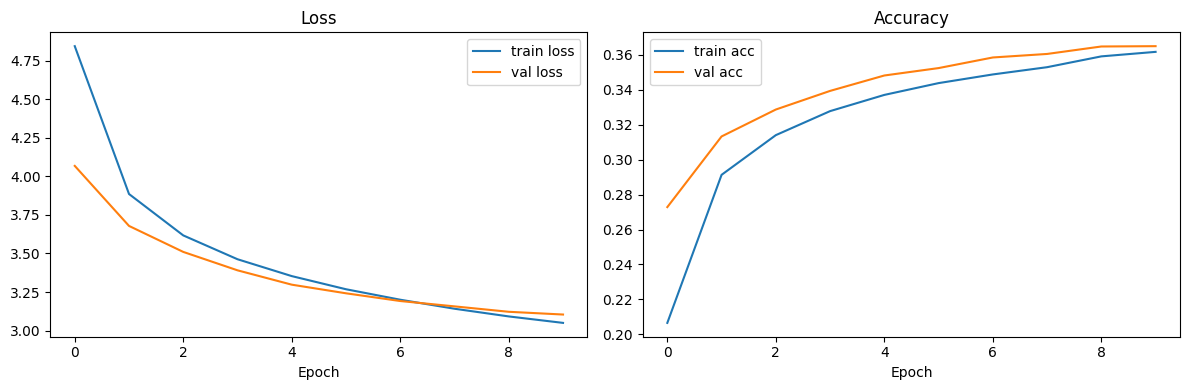

[✓] Best val accuracy: 0.3649


In [ ]:
fig,(ax1, ax2)=plt.subplots(1, 2, figsize=(12, 4))

ax1.plot(hist["loss"],     label="train loss")
ax1.plot(hist["val_loss"], label="val loss")
ax1.set_title("Loss"); ax1.set_xlabel("Epoch"); ax1.legend()

ax2.plot(hist["accuracy"],     label="train acc")
ax2.plot(hist["val_accuracy"], label="val acc")
ax2.set_title("Accuracy"); ax2.set_xlabel("Epoch"); ax2.legend()

plt.tight_layout()
plt.savefig("training_curves.png", dpi=120)
plt.show()
print(f"[✓] Best val accuracy: {max(hist['val_accuracy']):.4f}")

In [33]:
from tensorflow.keras.preprocessing.sequence import pad_sequences
import numpy as np

def generate_caption(model, feature, word2idx, idx2word, max_length):
    if feature.ndim == 1:
        feature = np.expand_dims(feature, axis=0)
    in_text = "startseq"
    for _ in range(max_length):
        seq = [word2idx.get(w, word2idx["<unk>"]) for w in in_text.split()]
        seq = pad_sequences([seq], maxlen=max_length)
        y_pred = model.predict([feature, seq], verbose=0)
        y_pred = np.argmax(y_pred)
        word = idx2word.get(y_pred, None)
        if word is None:
            break
        in_text += " " + word
        if word == "endseq":
            break
    final_caption = in_text.replace("startseq", "").replace("endseq", "").strip()
    return final_caption


In [37]:
img_path = "your_img.jpg"
extractor = build_feature_extractor()
img = load_and_preprocess(img_path)
feature = extractor.predict(img, verbose=0)

[✓] ResNet50 extractor ready
    Input  : (None, 224, 224, 3)
    Output : (None, 2048)


In [38]:
caption = generate_caption(model, feature, word2idx, idx2word, max_length)

print("Generated Caption:", caption)

Generated Caption: a black and white dog is running through the snow


In [21]:
from tensorflow.keras.models import load_model

model.save("best_caption_model.keras")